# Analyse vegetation productivity from MODIS Products using openEO API

This notebook demonstrates how MODIS products available through the Copernicus Data Space Ecosystem (CDSE) can be accessed and analysed with the openEO API.

Here, we use simple openEO processes to load environmental and vegetation products to monitor environmental conditions and vegetation dynamics. Please note that the focus of this notebook is on demonstrating the openEO workflow rather than developing a complete MODIS application.

To explore more on about the data that are avilable in the CDSE STAC catalogue please visit [this notebook](./MODIS_data_using_openEO.ipynb).

We start by importing the libraries used to connect to CDSE, build openEO processes, and inspect the downloaded results.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


For this usecase, we select a small area of interest and a one-year period.

In [3]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [-6.25, 39.1],
            [-6.05, 39.1],
            [-6.05, 39.3],
            [-6.25, 39.3],
            [-6.25, 39.1]
          ]
        ]
      }
    }
  ]
}

temporal_extent = ["2025-01-01", "2026-01-01"]

Since this notebooks uses several different MODIS products, it is convenient to wrap the STAC-loading logic in a small helper function that takes a collection ID and a list of bands, and returns the corresponding data cube for our area and time range.

In [4]:
def get_stac_cube(collection, bands):
    url = f"https://stac.dataspace.copernicus.eu/v1/collections/{collection}"
    stac_cube = connection.load_stac(url,
                                    temporal_extent=temporal_extent,
                                    spatial_extent=aoi,
                                    bands=bands
                                    )
    return stac_cube

Let us load five MODIS products from the CDSE STAC catalogue using openEO's `load_stac` process. These products provide complementary environmental and vegetation observations for this example:

- **LST** (1 km): land-surface temperature
- **NDVI** (500 m): vegetation greenness
- **GPP** (500 m): gross primary productivity

In [5]:
# lst
lst_collection_id = "modis-aqua-myd11a2"
lst_bands = ["LST_Day_1km"]
lst_cube = get_stac_cube(lst_collection_id, lst_bands)

# ndvi 
ndvi_collection_id = "modis-aqua-myd13a1"     
ndvi_bands = ["500m 16 days NDVI"]
ndvi_cube = get_stac_cube(ndvi_collection_id, ndvi_bands)

#gpp
gpp_collection_id = "modis-aqua-myd17a2h"
gpp_bands = ["Gpp_500m"]
gpp_cube = get_stac_cube(gpp_collection_id, gpp_bands)

For the productivity comparison, we aggregate the GPP and NDVI observations to monthly means.

In [6]:
monthly_gpp = gpp_cube.aggregate_temporal_period(
    period="month",
    reducer="mean"
)
monthly_ndvi = ndvi_cube.aggregate_temporal_period(
    period="month", 
    reducer="mean"
)

Let us now use an openEO UDF to subtract each pixel's temporal mean from its LST values, highlighting periods that are warmer or cooler than usual.

In [7]:
# Build a UDF object from an inline string with Python source code.
udf = openeo.UDF(
"""
import xarray

def apply_datacube(cube: xarray.DataArray, context: dict) -> xarray.DataArray:
    # Calculate the mean of the data cube along the time dimension
    mean_cube = cube.mean(dim='t')
    # Subtract the mean from the original data cube to get the anomaly
    cube = cube - mean_cube
    return cube
"""
)

# Apply the UDF to a cube.
lst_anomaly = lst_cube.apply_dimension(process=udf, dimension="t")

In [8]:
lst_anomaly

Next, let us run a batch job to get the anomaly output for further inspection:

In [9]:
job = lst_anomaly.create_job(title="LST Anomaly")
job.start_and_wait()

0:00:00 Job 'j-26090716215745168b6039f9ea6acebc': send 'start'
0:00:06 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:00:11 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:00:17 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:00:25 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:00:35 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:00:48 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:01:03 Job 'j-26090716215745168b6039f9ea6acebc': queued (progress 0%)
0:01:22 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:01:46 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:02:16 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:02:54 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:03:41 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:04:39 Job 'j-26090716215745168b6039f9ea6acebc': running (progress N/A)
0:

<BatchJob job_id='j-26090716215745168b6039f9ea6acebc'>

### Download the processed anomaly

After the batch job finishes, we download the generated GeoTIFF files for local inspection.

In [10]:
results = job.get_results()
results.download_files("lst_anomaly")

[WindowsPath('lst_anomaly/openEO_2025-01-01Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-01-09Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-01-17Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-01-25Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-02-02Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-02-10Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-02-18Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-02-26Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-03-06Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-03-14Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-03-22Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-03-30Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-04-07Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-04-15Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-04-23Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-05-01Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-05-09Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-05-17Z.tif'),
 WindowsPath('lst_anomaly/openEO_2025-05-25Z.tif'),
 WindowsPath

Let us plot all downloaded time slices as subplots to compare the spatial pattern over time.

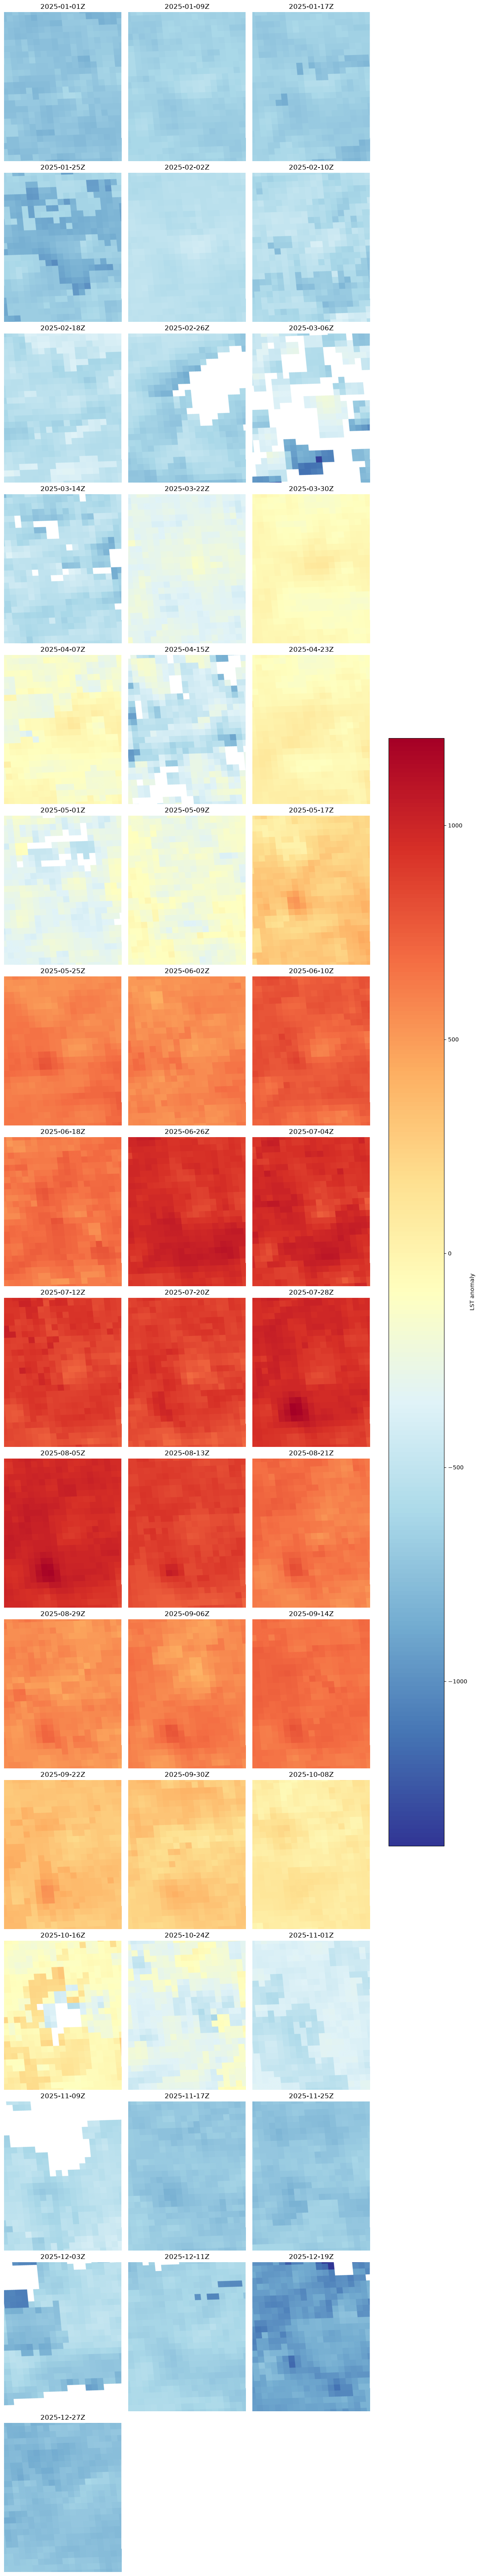

In [11]:
# Visualize all downloaded time slices
files = sorted(Path("lst_anomaly").glob("*.tif"))
arrays = []
for file in files:
    with rasterio.open(file) as dataset:
        arrays.append(dataset.read(1, masked=True))
vmin = min(np.nanmin(array) for array in arrays)
vmax = max(np.nanmax(array) for array in arrays)
columns = min(3, len(files))
rows = math.ceil(len(files) / columns)
fig, axes = plt.subplots(
    rows, columns, figsize=(4 * columns, 4 * rows), squeeze=False, constrained_layout=True
)
for axis, file, array in zip(axes.flat, files, arrays):
    image = axis.imshow(array, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
    axis.set_title(file.stem.replace("openEO_", ""))
    axis.axis("off")
for axis in axes.flat[len(files):]:
    axis.axis("off")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.6, label="LST anomaly")
plt.show()

The above plots shows the spatial distribution of the LST anomaly across the year. Positive and negative values indicate areas that are warmer or cooler than their temporal average.

We reduce the anomaly cube spatially to obtain one mean value per time step for a simple time-series view.

In [12]:
lst_anomaly_mean = lst_anomaly.aggregate_spatial(
    geometries=aoi,
    reducer="mean"
)
lst_anomaly_mean.execute_batch(title="LST Anomaly Mean", outputfile="env_prod/lst_anomaly_mean.csv")

0:00:00 Job 'j-2609071636384cbeac42dfdf17b86b91': send 'start'
0:00:07 Job 'j-2609071636384cbeac42dfdf17b86b91': queued (progress 0%)
0:00:12 Job 'j-2609071636384cbeac42dfdf17b86b91': queued (progress 0%)
0:00:18 Job 'j-2609071636384cbeac42dfdf17b86b91': queued (progress 0%)
0:00:26 Job 'j-2609071636384cbeac42dfdf17b86b91': queued (progress 0%)
0:00:36 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:00:49 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:01:05 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:01:24 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:01:48 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:02:18 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:02:56 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:03:42 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N/A)
0:04:41 Job 'j-2609071636384cbeac42dfdf17b86b91': running (progress N

<BatchJob job_id='j-2609071636384cbeac42dfdf17b86b91'>

 The plot below shows how the mean LST anomaly changes through the selected year.

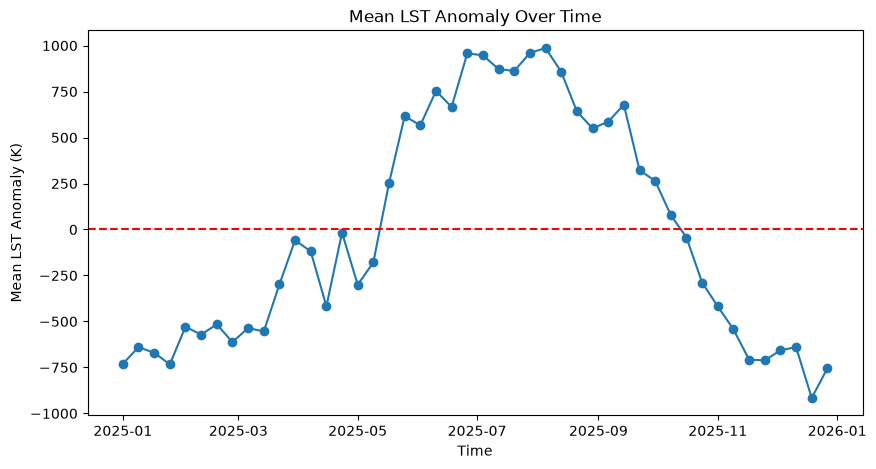

In [13]:
df = pd.read_csv("env_prod/lst_anomaly_mean.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['LST_Day_1km'], marker='o')
plt.title('Mean LST Anomaly Over Time')
plt.xlabel('Time')
plt.ylabel('Mean LST Anomaly (K)')
plt.axhline(y=0, color='r', linestyle='--', label='Zero Anomaly')
plt.show()


As seen in the timeseries the LST anomaly is higher in the summer season and it lowers down during the winter period.

To compare productivity and vegetation greenness, combine monthly GPP and NDVI in one openEO data cube and calculate GPP per NDVI as a simple relative productivity indicator.

In [14]:
# Productivity Efficiency

merged_gpp_ndvi = monthly_gpp.merge_cubes(monthly_ndvi)
gpp_per_ndvi = merged_gpp_ndvi.band("Gpp_500m") / merged_gpp_ndvi.band("500m 16 days NDVI")

In [15]:
job = gpp_per_ndvi.create_job(title="GPP per NDVI")
job.start_and_wait()

0:00:00 Job 'j-2609071650254a41a5a4b2556c97b049': send 'start'
0:00:08 Job 'j-2609071650254a41a5a4b2556c97b049': queued (progress 0%)
0:00:13 Job 'j-2609071650254a41a5a4b2556c97b049': queued (progress 0%)
0:00:20 Job 'j-2609071650254a41a5a4b2556c97b049': queued (progress 0%)
0:00:28 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:00:38 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:00:50 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:01:05 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:01:25 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:01:49 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:02:19 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:02:57 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:03:43 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress N/A)
0:04:42 Job 'j-2609071650254a41a5a4b2556c97b049': running (progress

<BatchJob job_id='j-2609071650254a41a5a4b2556c97b049'>

Once processing is complete, we download the GPP-per-NDVI GeoTIFF files.

In [16]:
results = job.get_results()
results.download_files("env_prod/gppperndvi/")

[WindowsPath('env_prod/gppperndvi/openEO_2025-01-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-02-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-03-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-04-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-05-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-06-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-07-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-08-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-09-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-10-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-11-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/openEO_2025-12-01Z.tif'),
 WindowsPath('env_prod/gppperndvi/job-results.json')]

Let us visualise all GPP-per-NDVI time slices. 

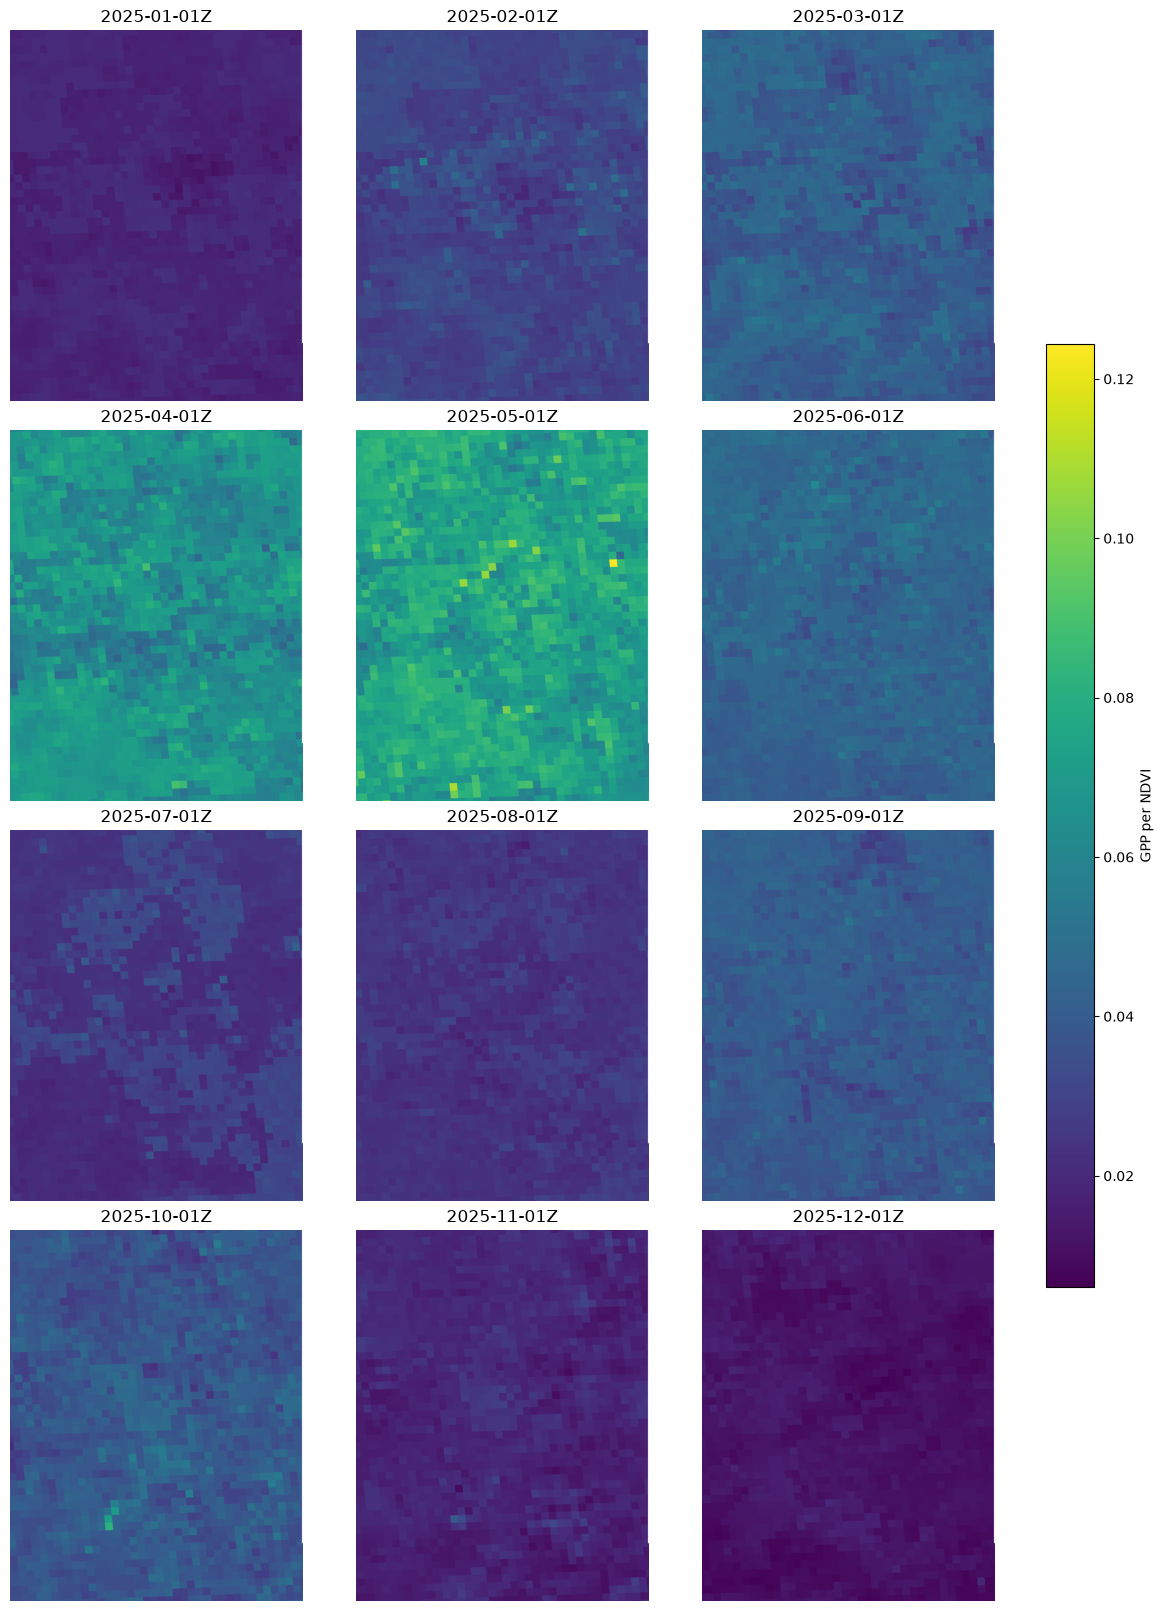

In [17]:
files = sorted(Path("env_prod/gppperndvi").glob("*.tif"))
arrays = []
for file in files:
    with rasterio.open(file) as dataset:
        arrays.append(dataset.read(1, masked=True))
vmin = min(np.nanmin(array) for array in arrays)
vmax = max(np.nanmax(array) for array in arrays)
columns = min(3, len(files))
rows = math.ceil(len(files) / columns)
fig, axes = plt.subplots(
    rows, columns, figsize=(4 * columns, 4 * rows), squeeze=False, constrained_layout=True
)
for axis, file, array in zip(axes.flat, files, arrays):
    image = axis.imshow(array, cmap="viridis", vmin=vmin, vmax=vmax)
    axis.set_title(file.stem.replace("openEO_", ""))
    axis.axis("off")
for axis in axes.flat[len(files):]:
    axis.axis("off")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.6, label="GPP per NDVI")
plt.show()